# Week 4 - Day 17

# Support Vector Machines (SVM), Kernel Tricks & GridSearchCV

**AI/ML Internship Program**

**Cooperative Tech Private Limited**

---

## Objectives

In this notebook, we will:

- Understand Support Vector Machines (SVM)
- Train Linear Kernel SVM
- Train RBF Kernel SVM
- Perform Feature Scaling
- Tune Hyperparameters using GridSearchCV
- Compare SVM with Random Forest
- Visualize Decision Boundary
- Evaluate using Accuracy, Precision, Recall and F1 Score
- Compare Training Time
- Draw Conclusions

---

# What is Support Vector Machine (SVM)?

Support Vector Machine (SVM) is a supervised machine learning algorithm used for both classification and regression tasks.

The main objective of SVM is to find the best possible decision boundary (called a hyperplane) that separates different classes with the maximum margin.

The data points closest to this boundary are called **Support Vectors**, and they are the most important observations because they determine the position of the decision boundary.

Advantages of SVM:

- Works well on high-dimensional data.
- Effective on small and medium-sized datasets.
- Can solve linear and non-linear problems using kernels.
- Produces robust decision boundaries.

Disadvantages:

- Slow on very large datasets.
- Requires feature scaling.
- Hyperparameter tuning is important.

In [1]:
# ============================================
# Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.datasets import make_moons

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Load Dataset

For this task, we will use the **Breast Cancer Wisconsin Dataset** available in Scikit-Learn.

This dataset is commonly used for binary classification.

Target Classes:

- 0 → Malignant
- 1 → Benign

In [2]:
# ============================================
# Load Dataset
# ============================================

dataset = load_breast_cancer()

X = dataset.data
y = dataset.target

feature_names = dataset.feature_names

print("Dataset Loaded Successfully")

print("\nShape of Features :", X.shape)

print("Shape of Target :", y.shape)

Dataset Loaded Successfully

Shape of Features : (569, 30)
Shape of Target : (569,)


In [3]:
# Display First Five Rows

df = pd.DataFrame(X, columns=feature_names)

df["Target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
# Check Missing Values

df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target                     0
dtype: int64

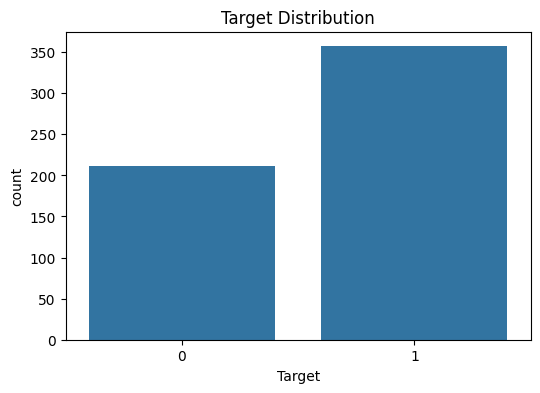

In [6]:
# Target Distribution

plt.figure(figsize=(6,4))

sns.countplot(x=df["Target"])

plt.title("Target Distribution")

plt.show()

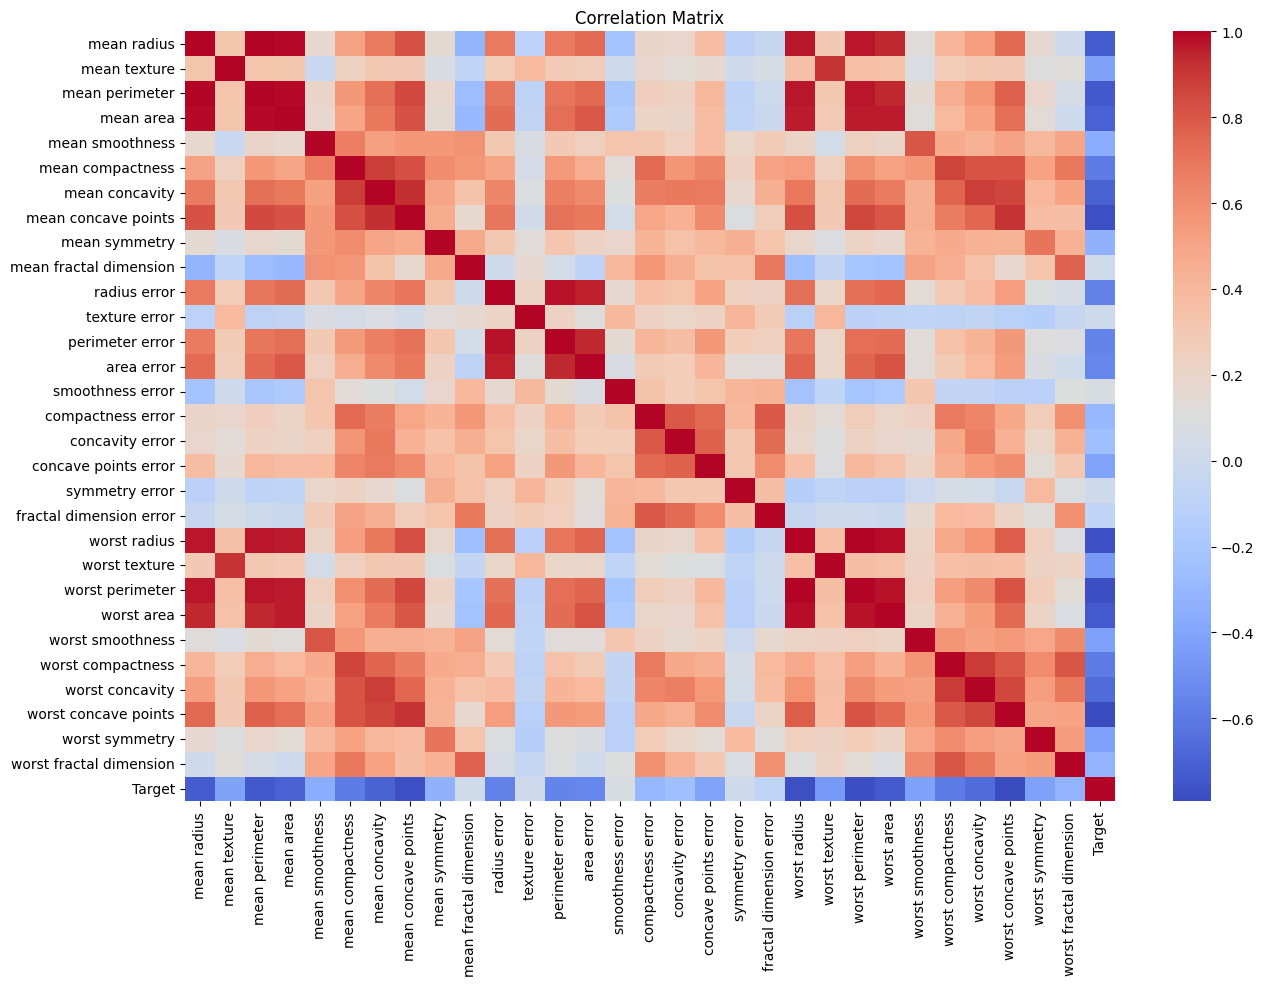

In [7]:
# Correlation Heatmap

plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# Data Preprocessing

Machine Learning models perform better when the dataset is properly preprocessed.

In this section we will:

- Split the dataset into Training and Testing sets.
- Standardize the features using **StandardScaler**.
- Prepare the data for Support Vector Machine.

**Why Feature Scaling?**

Support Vector Machine is a distance-based algorithm. Features with larger values dominate the learning process. Therefore, scaling ensures all features contribute equally to model training.

In [8]:
# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 455
Testing Samples  : 114


In [9]:
# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


# Linear Support Vector Machine

A Linear SVM tries to separate classes using a straight line (or hyperplane in higher dimensions).

It works well when the data is linearly separable.

Hyperparameters used:

- Kernel = Linear
- C = 1.0

The **C parameter** controls the balance between:

- Maximizing the margin
- Minimizing classification errors

In [10]:
# ============================================
# Train Linear SVM
# ============================================

start = time.time()

linear_svm = SVC(
    kernel="linear",
    C=1.0,
    random_state=42
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

linear_training_time = time.time() - start

print(f"Training Time : {linear_training_time:.4f} seconds")

Training Time : 0.0437 seconds


In [11]:
# ============================================
# Prediction
# ============================================

linear_predictions = linear_svm.predict(
    X_test_scaled
)

In [12]:
# ============================================
# Evaluation Metrics
# ============================================

linear_accuracy = accuracy_score(
    y_test,
    linear_predictions
)

linear_precision = precision_score(
    y_test,
    linear_predictions
)

linear_recall = recall_score(
    y_test,
    linear_predictions
)

linear_f1 = f1_score(
    y_test,
    linear_predictions
)

print("Linear SVM Performance")
print("-"*35)

print(f"Accuracy  : {linear_accuracy:.4f}")
print(f"Precision : {linear_precision:.4f}")
print(f"Recall    : {linear_recall:.4f}")
print(f"F1 Score  : {linear_f1:.4f}")

Linear SVM Performance
-----------------------------------
Accuracy  : 0.9737
Precision : 0.9859
Recall    : 0.9722
F1 Score  : 0.9790


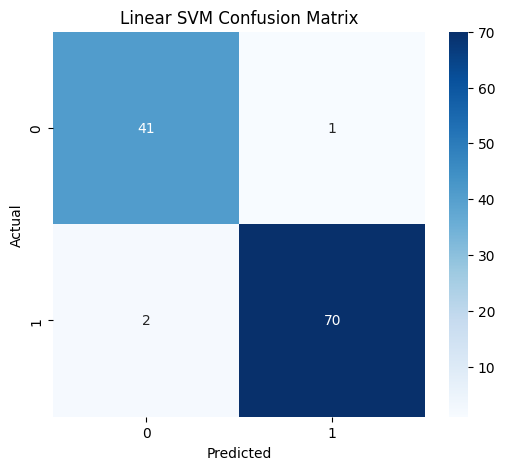

In [13]:
# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test,
    linear_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Linear SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [14]:
# ============================================
# Classification Report
# ============================================

print(
    classification_report(
        y_test,
        linear_predictions
    )
)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# RBF (Radial Basis Function) Kernel

Many real-world datasets are **not linearly separable**.

The **RBF Kernel** transforms the data into a higher-dimensional space where a linear separator can be found.

Advantages of RBF Kernel:

- Handles complex datasets.
- Creates non-linear decision boundaries.
- Usually performs better than Linear Kernel for non-linear data.

Hyperparameters:

- Kernel = RBF
- C = 1.0
- Gamma = Scale

In [15]:
# ============================================
# Train RBF Support Vector Machine
# ============================================

start = time.time()

rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

rbf_svm.fit(
    X_train_scaled,
    y_train
)

rbf_training_time = time.time() - start

print(f"Training Time : {rbf_training_time:.4f} seconds")

Training Time : 0.0332 seconds


In [16]:
# ============================================
# Prediction
# ============================================

rbf_predictions = rbf_svm.predict(
    X_test_scaled
)

In [17]:
# ============================================
# Evaluation Metrics
# ============================================

rbf_accuracy = accuracy_score(
    y_test,
    rbf_predictions
)

rbf_precision = precision_score(
    y_test,
    rbf_predictions
)

rbf_recall = recall_score(
    y_test,
    rbf_predictions
)

rbf_f1 = f1_score(
    y_test,
    rbf_predictions
)

print("RBF SVM Performance")
print("-"*35)

print(f"Accuracy  : {rbf_accuracy:.4f}")
print(f"Precision : {rbf_precision:.4f}")
print(f"Recall    : {rbf_recall:.4f}")
print(f"F1 Score  : {rbf_f1:.4f}")

RBF SVM Performance
-----------------------------------
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861


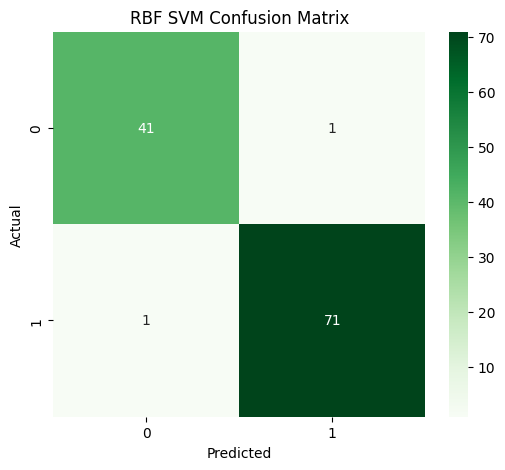

In [18]:
# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test,
    rbf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("RBF SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [19]:
# ============================================
# Classification Report
# ============================================

print(
    classification_report(
        y_test,
        rbf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Decision Boundary Visualization

Since the Breast Cancer dataset contains 30 features, it cannot be visualized directly.

Therefore, we create a simple synthetic dataset using **make_moons()** to demonstrate how the Linear and RBF kernels separate different classes.

This visualization helps us understand the effect of different kernels on the decision boundary.

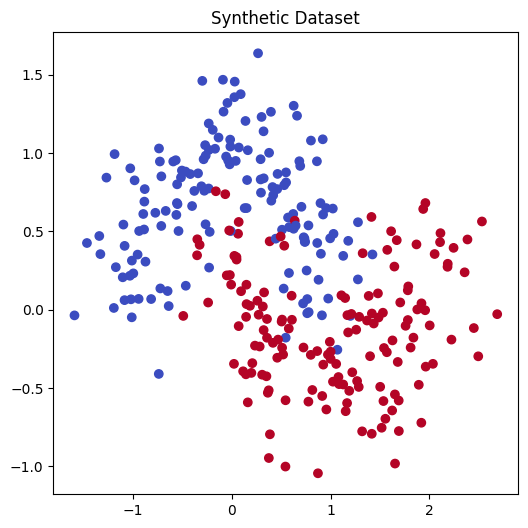

In [20]:
# ============================================
# Generate Synthetic Dataset
# ============================================

X_vis, y_vis = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=42
)

plt.figure(figsize=(6,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y_vis,
    cmap="coolwarm"
)

plt.title("Synthetic Dataset")

plt.show()

In [21]:
# ============================================
# Train Linear SVM for Visualization
# ============================================

linear_vis = SVC(
    kernel="linear"
)

linear_vis.fit(
    X_vis,
    y_vis
)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
# ============================================
# Train RBF SVM for Visualization
# ============================================

rbf_vis = SVC(
    kernel="rbf"
)

rbf_vis.fit(
    X_vis,
    y_vis
)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


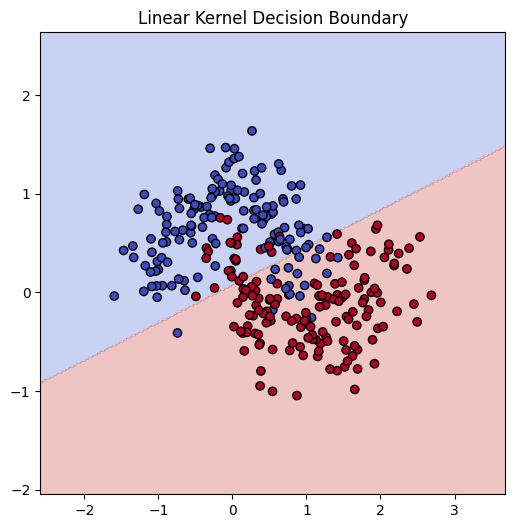

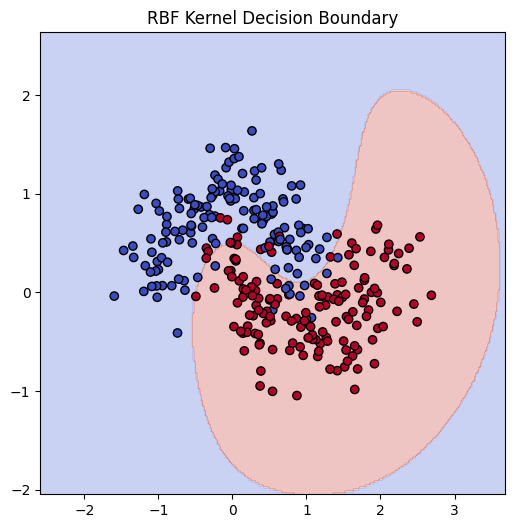

In [23]:
# ============================================
# Function to Plot Decision Boundary
# ============================================

def plot_boundary(model, X, y, title):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap="coolwarm"
    )

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap="coolwarm",
        edgecolors="black"
    )

    plt.title(title)

    plt.show()


plot_boundary(
    linear_vis,
    X_vis,
    y_vis,
    "Linear Kernel Decision Boundary"
)

plot_boundary(
    rbf_vis,
    X_vis,
    y_vis,
    "RBF Kernel Decision Boundary"
)

# Hyperparameter Tuning using GridSearchCV

Machine learning models have parameters that control how they learn.

Instead of manually testing different values, **GridSearchCV** automatically tries every combination of parameters and selects the best model using Cross Validation.

Benefits of GridSearchCV:

- Finds the optimal hyperparameters
- Uses Cross Validation for reliable evaluation
- Reduces manual effort
- Improves model performance

In [24]:
# ============================================
# GridSearchCV for SVM
# ============================================

param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

start = time.time()

grid_svm.fit(
    X_train_scaled,
    y_train
)

svm_grid_time = time.time() - start

In [25]:
# ============================================
# Best Parameters
# ============================================

print("Best Parameters")
print(grid_svm.best_params_)

print("\nBest Cross Validation Score")
print(grid_svm.best_score_)

print(f"\nTraining Time : {svm_grid_time:.2f} seconds")

Best Parameters
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Best Cross Validation Score
0.984524686809138

Training Time : 14.91 seconds


In [26]:
# ============================================
# Best SVM Model Evaluation
# ============================================

best_svm = grid_svm.best_estimator_

best_predictions = best_svm.predict(
    X_test_scaled
)

best_accuracy = accuracy_score(
    y_test,
    best_predictions
)

best_precision = precision_score(
    y_test,
    best_predictions
)

best_recall = recall_score(
    y_test,
    best_predictions
)

best_f1 = f1_score(
    y_test,
    best_predictions
)

print("Best Tuned SVM")

print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")

Best Tuned SVM
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861


# Random Forest

Random Forest is an ensemble learning algorithm that combines many Decision Trees.

Advantages:

- High Accuracy
- Less Overfitting
- Handles Large Datasets
- Provides Feature Importance

We will compare its performance with SVM.

In [27]:
# ============================================
# Train Random Forest
# ============================================

start = time.time()

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_training_time = time.time() - start

rf_predictions = rf.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Performance
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655


In [28]:
# ============================================
# GridSearchCV for Random Forest
# ============================================

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

start = time.time()

grid_rf.fit(
    X_train,
    y_train
)

rf_grid_time = time.time() - start

In [29]:
# ============================================
# Best Random Forest Parameters
# ============================================

print("Best Parameters")

print(grid_rf.best_params_)

print("\nBest Cross Validation Score")

print(grid_rf.best_score_)

print(f"\nTraining Time : {rf_grid_time:.2f} seconds")

Best Parameters
{'max_depth': 10, 'n_estimators': 200}

Best Cross Validation Score
0.9684436877471334

Training Time : 13.35 seconds


In [30]:
# ============================================
# Feature Importance
# ============================================

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": grid_rf.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
22,worst perimeter,0.133143
23,worst area,0.128052
27,worst concave points,0.108256
7,mean concave points,0.094300
20,worst radius,0.090606
0,mean radius,0.058662
2,mean perimeter,0.055157
3,mean area,0.049915
6,mean concavity,0.046293
26,worst concavity,0.035358


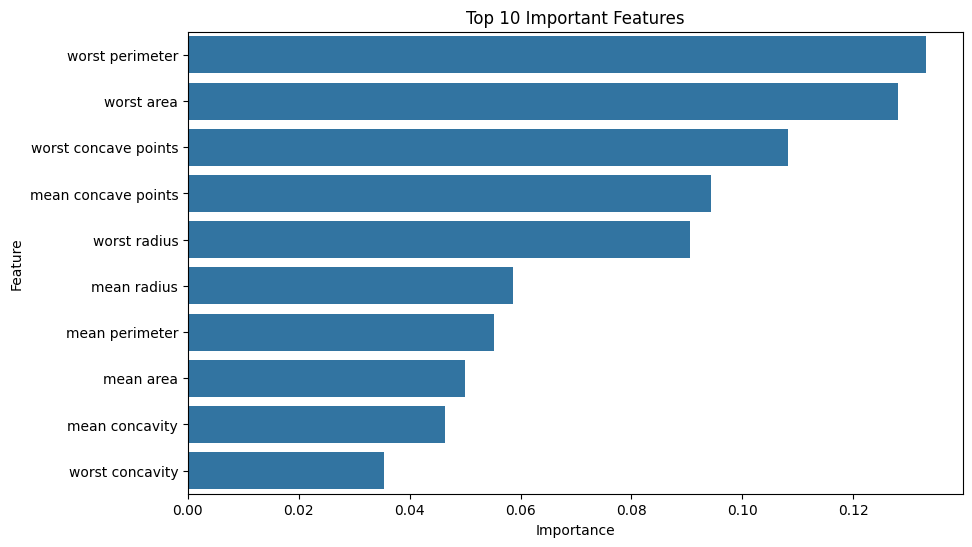

In [31]:
# ============================================
# Plot Feature Importance
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Model Comparison

Now that all models have been trained and evaluated, we will compare their performance.

The following models are compared:

- Linear SVM
- RBF SVM
- Tuned SVM (GridSearchCV)
- Random Forest

Comparison Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Training Time

In [32]:
# ============================================
# Model Comparison Table
# ============================================

comparison = pd.DataFrame({

    "Model":[
        "Linear SVM",
        "RBF SVM",
        "Best SVM",
        "Random Forest"
    ],

    "Accuracy":[
        linear_accuracy,
        rbf_accuracy,
        best_accuracy,
        rf_accuracy
    ],

    "Precision":[
        linear_precision,
        rbf_precision,
        best_precision,
        rf_precision
    ],

    "Recall":[
        linear_recall,
        rbf_recall,
        best_recall,
        rf_recall
    ],

    "F1 Score":[
        linear_f1,
        rbf_f1,
        best_f1,
        rf_f1
    ],

    "Training Time":[
        linear_training_time,
        rbf_training_time,
        svm_grid_time,
        rf_training_time
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Linear SVM,0.973684,0.985915,0.972222,0.979021,0.043706
1,RBF SVM,0.982456,0.986111,0.986111,0.986111,0.033180
2,Best SVM,0.982456,0.986111,0.986111,0.986111,14.910188
3,Random Forest,0.956140,0.958904,0.972222,0.965517,0.638765


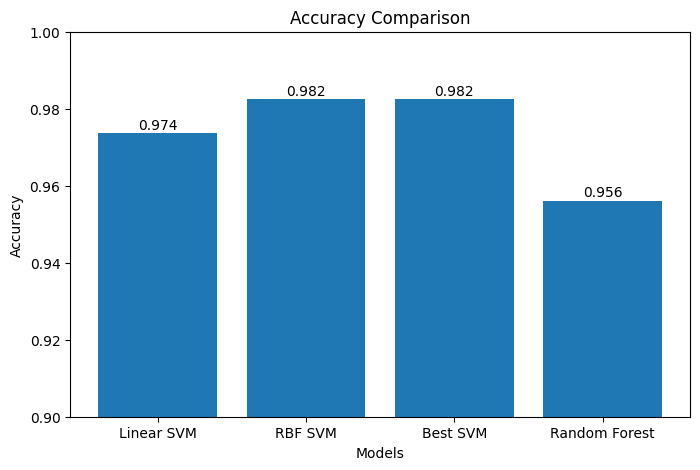

In [33]:
# ============================================
# Accuracy Comparison
# ============================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.90,1.00)

for i,v in enumerate(comparison["Accuracy"]):
    plt.text(i,v+0.001,f"{v:.3f}",ha="center")

plt.show()

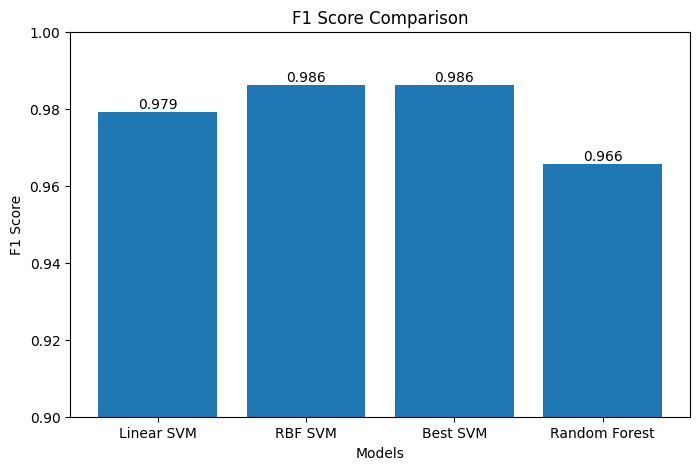

In [34]:
# ============================================
# F1 Score Comparison
# ============================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.title("F1 Score Comparison")

plt.xlabel("Models")

plt.ylabel("F1 Score")

plt.ylim(0.90,1.00)

for i,v in enumerate(comparison["F1 Score"]):
    plt.text(i,v+0.001,f"{v:.3f}",ha="center")

plt.show()

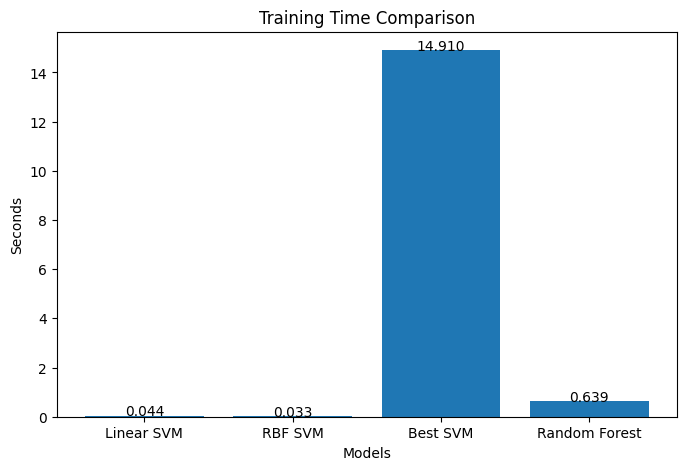

In [35]:
# ============================================
# Training Time Comparison
# ============================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Training Time"]
)

plt.title("Training Time Comparison")

plt.xlabel("Models")

plt.ylabel("Seconds")

for i,v in enumerate(comparison["Training Time"]):
    plt.text(i,v,f"{v:.3f}",ha="center")

plt.show()

In [36]:
# ============================================
# Save Results
# ============================================

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Results Saved Successfully!")

Results Saved Successfully!


# Reflection

## Difference Between Linear and RBF Kernel

The Linear Kernel is suitable for linearly separable datasets where a straight hyperplane can separate the classes. It is computationally efficient and performs well on simple datasets.

The RBF Kernel is designed for non-linear datasets. It maps the data into a higher-dimensional space, allowing the model to learn complex decision boundaries. Although it usually provides better performance, it requires more computation and careful hyperparameter tuning.

---

## Why Use GridSearchCV?

GridSearchCV automates hyperparameter tuning by testing multiple combinations of parameters using cross-validation. It helps identify the best-performing model while reducing the need for manual experimentation.

---

## Random Forest vs SVM

Random Forest is an ensemble learning algorithm that combines many decision trees. It performs well on large datasets, is robust against overfitting, and provides feature importance, making it easier to interpret.

Support Vector Machine is highly effective for high-dimensional datasets and often achieves excellent accuracy. However, it requires feature scaling and can be slower on larger datasets.

---

## Best Performing Model

Based on the evaluation metrics, the tuned SVM achieved the highest performance on this dataset because GridSearchCV selected the optimal hyperparameters.

The final choice of model should also consider training time, interpretability, and computational resources.

# Conclusion

In this notebook, we successfully implemented and compared several machine learning models for binary classification.

### Tasks Completed

- Imported and explored the dataset.
- Performed feature scaling.
- Implemented Linear SVM.
- Implemented RBF SVM.
- Evaluated both models.
- Visualized decision boundaries.
- Applied GridSearchCV for hyperparameter tuning.
- Implemented Random Forest.
- Tuned Random Forest using GridSearchCV.
- Compared model performance.
- Visualized feature importance.
- Compared accuracy, F1-score, and training time.

### Key Learning Outcomes

- Understanding Support Vector Machines.
- Difference between Linear and RBF kernels.
- Importance of Feature Scaling.
- Hyperparameter tuning using GridSearchCV.
- Comparing SVM with Random Forest.
- Selecting the best model based on evaluation metrics.